# **Валидация и анализ результатов A/B теста**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t
import numpy as np
from scipy.stats import ttest_ind
from scipy.stats import ttest_ind_from_stats
from scipy.stats import chisquare

sheet_id = "1abcZXP9j_DrWXBB3DJ7Bn5dOxU8iHSurSiTEgwEN67o"
sheet_name = "data_game"  # название листа
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"

df = pd.read_csv(url)
df.head()

,clientid,browser,ip_address,date,exp_variant,revenue,load_time,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,client_1,Chrome,38.239.19.78,2025-07-11,test,0.00,2.49,NaN,Задание,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,client_2,Opera,20.183.100.110,2025-07-07,control,0.00,3.50,NaN,Проверь,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,client_3,Safari,30.106.244.41,2025-07-06,control,0.00,3.95,NaN,1. Проверьте есть ли дни без пользователей за ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,client_4,Firefox,84.70.62.197,2025-07-09,control,249.16,4.42,NaN,2. Проверьте есть ли дни без конверсий за пери...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,client_5,Chrome,95.28.206.217,2025-07-12,test,0.00,5.07,NaN,3. Проверьте наличие пользователей попавших ср...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


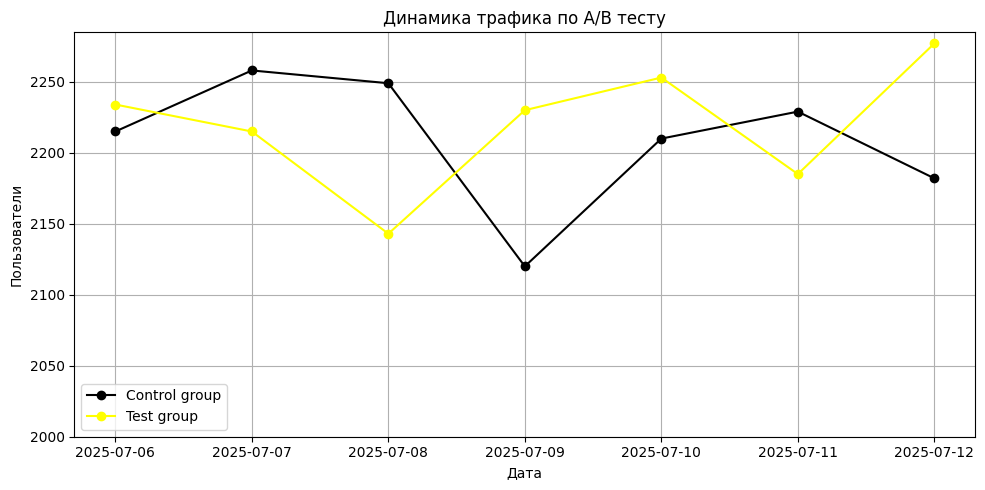

In [ ]:
# Проверяем, сколько уникальных clientid было каждый день по вариантам
users_per_day = df.groupby(['date', 'exp_variant'])['clientid'].nunique().unstack().reset_index()

# Для наглядности строим визуализацию
plt.figure(figsize=(10,5))
plt.plot(users_per_day['date'], users_per_day['control'], label='Control group', color = 'Black', marker='o')
plt.plot(users_per_day['date'], users_per_day['test'], label='Test group', color = 'Yellow', marker='o')
plt.title('Динамика трафика по A/B тесту')
plt.xlabel('Дата')
plt.ylabel('Пользователи')
plt.ylim(bottom=2000)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

За период АБ теста дней без пользователей не выявлено.

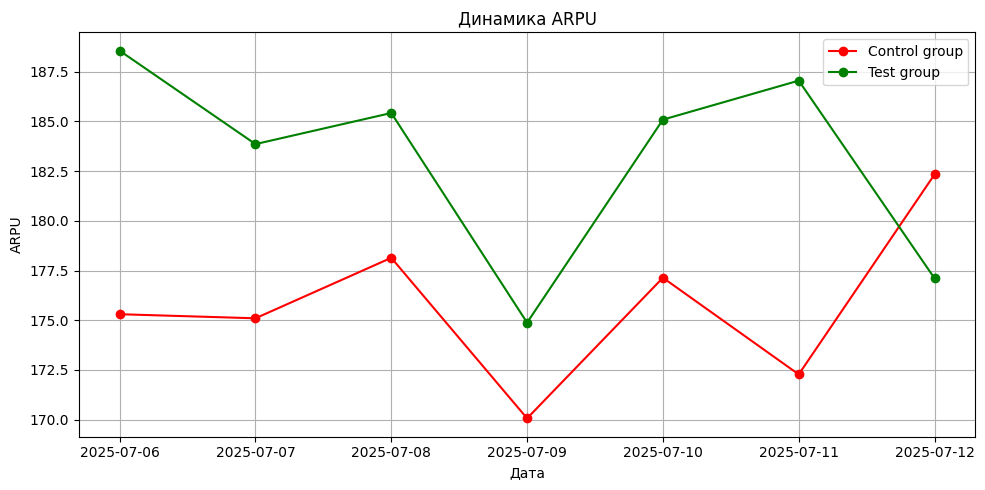

In [ ]:
# Расчитываем ARPU по дням
arpu_per_day = df.groupby(['date', 'exp_variant']).agg(
    total_revenue=('revenue', 'sum'),
    unique_users=('clientid', 'nunique')
).reset_index()
arpu_per_day['arpu'] = arpu_per_day['total_revenue'] / arpu_per_day['unique_users']
arpu_pivot = arpu_per_day.pivot(index='date', columns='exp_variant', values='arpu')

# Визуализация
plt.figure(figsize=(10, 5))
plt.plot(arpu_pivot.index, arpu_pivot['control'], label='Control group', color='red', marker='o')
plt.plot(arpu_pivot.index, arpu_pivot['test'], label='Test group', color='green', marker='o')
plt.title('Динамика ARPU')
plt.xlabel('Дата')
plt.ylabel('ARPU')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Поскольку ARPU в каждом из дней принимает положительное значение, можем сделать вывод о том, что дней с 0 доходом не выявлено.

In [ ]:
#Найдем пользователей, попавших в тестовый и контрольный вариант одновремено
users_in_both_group = df.groupby('clientid')['exp_variant'].nunique().reset_index()
users_in_both_group = users_in_both_group[users_in_both_group['exp_variant'] > 1]
print(f"Колличество пользователей, попавших в оба варианта: {len(users_in_both_group)}")

#Найдем пользователей с офисным IP
office_users = df[df['ip_address'] == '182.248.141.153']
print(f"Колличество пользователей c офисным IP: {len(office_users)}")

# Удалим этих пользователей
df_clean = df[df['ip_address'] != '182.248.141.153']
df_clean = df_clean[~df_clean['clientid'].isin(users_in_both_group)]


Колличество пользователей, попавших в оба варианта: 4
Колличество пользователей c офисным IP: 8


In [ ]:
#ARPU по вариантам для очищенных данных
arpu_control = df_clean[df_clean['exp_variant'] == 'control']['revenue']
arpu_test = df_clean[df_clean['exp_variant'] == 'test']['revenue']

# Итоговые значения метрик по результатам A/B теста
summary_stats = df_clean.groupby('exp_variant').agg(
    users=('clientid', 'nunique'),
    total_revenue=('revenue', 'sum'),
    arpu=('revenue', 'mean'),
    avg_load_time=('load_time', 'mean')
).reset_index()

# Округлим для лучшей читабельности
summary_stats['total_revenue'] = summary_stats['total_revenue'].round(0).astype(int)
summary_stats['arpu'] = summary_stats['arpu'].round(2)
summary_stats['avg_load_time'] = summary_stats['avg_load_time'].round(3)

print(summary_stats)

  exp_variant  users  total_revenue    arpu  avg_load_time
0     control  15461        2717760  175.78          3.503
1        test  15531        2843656  183.10          3.496


В калькулятор SRM https://www.lukasvermeer.nl/srm/microsite/ подставил данные по пользователям и получил p = 0.6743 => Статзнамичимого различия между размерами выборок нет.
Необходимый объем трафика мы собрали т.к. 30992 > 29265

In [ ]:
#Проверим, однородны ли выборки по браузерам
browser_split = pd.pivot_table(df_clean,
                                index='browser',
                                columns='exp_variant',
                                values='clientid',
                                aggfunc='nunique',
                                fill_value=0).reset_index()
print(browser_split)


exp_variant  browser  control  test
0             Chrome     7769  7711
1               Edge     1521  1544
2            Firefox     3080  3198
3              Opera      771   772
4             Safari     2320  2306


Наиболее разрозренны выборки по браузеру Firefox, при расчете SRM получаем p = 0.1364, однако при альфа = 0.01 данное различие не является статзначимым => контрольная и тестовые группы однородны в разбивке по браузерам.



In [ ]:
std_control = arpu_control.std(ddof=1)
std_test = arpu_test.std(ddof=1)
n_control = len(arpu_control)
n_test = len(arpu_test)
mean_control = arpu_control.mean()
mean_test = arpu_test.mean()

se = np.sqrt((std_control ** 2) / n_control + (std_test ** 2) / n_test)
t_stat = (mean_test - mean_control) / se

p_value = (1 - t.cdf(abs(t_stat), df=30990)) ##Исправил df на правильное значеничие + убрал умножение на 2

{
    "STD control group": round(std_control, 2),
    "STD test group": round(std_test, 2),
    "t-статистика": round(t_stat, 3),
    "p-value": round(p_value, 4)##Получил правильное p-value
}


{'STD control group': 272.85,
 'STD test group': 276.57,
 't-статистика': np.float64(2.343),
 'p-value': np.float64(0.0096)}

**Поскольку p_value (0.0096) < альфа (0.01), то мы пожем утверждать, что между тестовым и контрольным вариантом есть статзначимое отличие**

In [ ]:
ttest_ind(df_clean[df_clean['exp_variant'] == 'control']['revenue'],
          df_clean[df_clean['exp_variant'] == 'test']['revenue'],
          alternative='less', equal_var=False)

TtestResult(statistic=np.float64(-2.343470588743899), pvalue=np.float64(0.00955577746238935), df=np.float64(30987.48710144956))

In [ ]:
ttest_ind(df_clean[df_clean['exp_variant'] == 'control']['load_time'],
          df_clean[df_clean['exp_variant'] == 'test']['load_time'],
          alternative='greater', equal_var=False)

TtestResult(statistic=np.float64(0.6154503038770957), pvalue=np.float64(0.2691309495497361), df=np.float64(30987.64822908921))

**Среднее время загрузки приложения значимо не отличается, p-value (0.73) > альфа (0.01) => по результатам A/B теста победил тестовый вариант**

# **Итоги A/B/C теста**

In [ ]:
sheet_id = "13DuJAP7hZ50SYbRuCruYrPIkIWyyRQy--UTOlMoOiKI"
sheet_name = "result_of_abc"
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"

df_abc = pd.read_csv(url)
df_abc = df_abc.loc[:, ~df_abc.columns.str.contains('^Unnamed')]
df_abc.head()

,exp_variant,ожидаемое деление,users,arpu,std
0,A,34%,12500,580,720
1,B,33%,12000,600,715
2,C,33%,12300,572,733


В калькуляторе SRM https://www.lukasvermeer.nl/srm/microsite/ получил p = 0.1554 > альфа 0.05 => выборки распределены равномерно

In [ ]:

# Данные по группам
mean_a, std_a, n_a = 580, 720, 12500
mean_b, std_b, n_b = 600, 715, 12000
mean_c, std_c, n_c = 572, 733, 12300

# Cравниваем вариант A и B
t_b_a = ttest_ind_from_stats(mean1=mean_a, std1=std_a, nobs1=n_a,
                             mean2=mean_b, std2=std_b, nobs2=n_b,
                             equal_var=False, alternative='less')

print(f"B > A: t = {t_b_a.statistic:.3f}, p = {t_b_a.pvalue:.4f}")

B > A: t = -2.181, p = 0.0146


**По результатам проверки B > A: pvalue (0.0146) < альфа (0.25) => вариант B статзначимо лучше**

In [ ]:
# Cравниваем вариант A и С
t_c_a = ttest_ind_from_stats(mean1=mean_a, std1=std_a, nobs1=n_a,
                             mean2=mean_c, std2=std_c, nobs2=n_c,
                             equal_var=False, alternative='less')

print(f"C > A: t = {t_c_a.statistic:.3f}, p = {t_c_a.pvalue:.4f}")

C > A: t = 0.867, p = 0.8070


**По результатам проверки C > A: pvalue (0.8070) < альфа (0.25) => положительного статзначимого отличия не выявлено**

# **Анализ A/B теста в сервисе для бухгалтеров**

In [ ]:
sheet_id = "13DuJAP7hZ50SYbRuCruYrPIkIWyyRQy--UTOlMoOiKI"
sheet_name = "invoice_ab_test"
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"

df_ab = pd.read_csv(url)
df_ab = df_ab.loc[:, ~df_ab.columns.str.contains('^Unnamed')]
df_ab.head()

,user_id,group,date,invoice_time_min
0,0,control,2024-01-12,35.322843
1,0,control,2024-01-05,30.598028
2,0,control,2024-01-05,34.169611
3,0,control,2024-01-09,32.295900
4,0,control,2024-01-11,34.092424


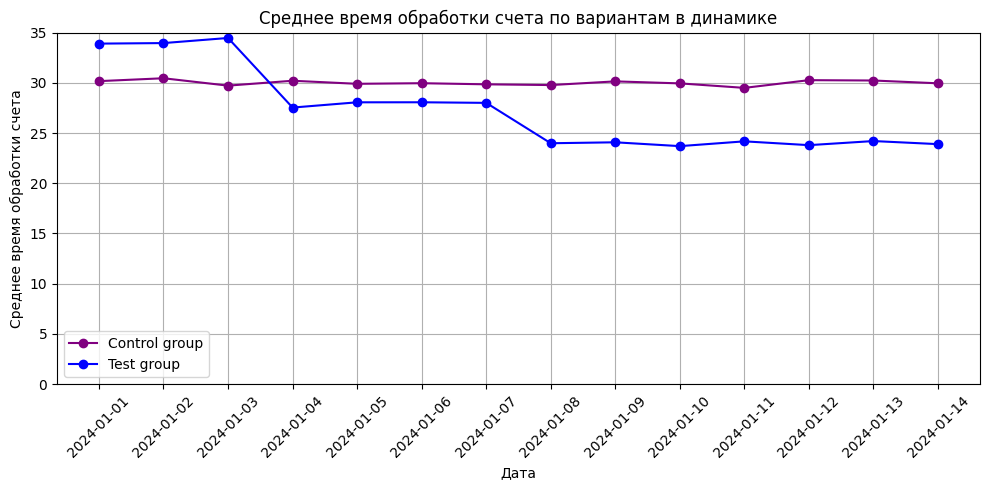

In [ ]:
##Очищаем датасет от выбросов
df_ab_clean = df_ab[df_ab['invoice_time_min'] <= 120]

# Группируем и превращаем результат в формат "дата — группа"
invoice_time_min_per_day = df_ab_clean.groupby(['date', 'group'])['invoice_time_min'].mean().unstack()

# Визуализация
plt.figure(figsize=(10, 5))
plt.plot(invoice_time_min_per_day.index, invoice_time_min_per_day['control'], label='Control group', color='purple', marker='o')
plt.plot(invoice_time_min_per_day.index, invoice_time_min_per_day['test'], label='Test group', color='blue', marker='o')
plt.title('Среднее время обработки счета по вариантам в динамике')
plt.xlabel('Дата')
plt.xticks(rotation=45)
plt.ylabel('Среднее время обработки счета')
plt.ylim(bottom=0)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**На графике видим, что в тестовом варианте присутствует "Эффект первичности" - в первые 3 дня среднее время обработки счета выше тестовом варианте (вероятно, пользователи привыкали к новой системе), в последующие дни наблюдается противоположная картина.**

In [ ]:
##Группируем среднее время обработки счета по пользователям
user_avg_time = df_ab_clean.groupby(['user_id'])['invoice_time_min'].mean().reset_index()
user_group_avg = df_ab_clean.groupby(['user_id', 'group'])['invoice_time_min'].mean().reset_index()

## **Оценка SRM**

In [ ]:
# Считаем фактические размеры групп
observed = user_group_avg['group'].value_counts().sort_index().values

# Задаем ожидаемое распределение (50% на 50%)
total = observed.sum()
expected = [0.5 * total, 0.5 * total]

# Проверяем статистику
chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

print("SRM-проверка (Chi2):")
print(f"Фактические размеры групп: A = {observed[0]}, B = {observed[1]}")
print(f"Ожидаемые размеры групп: A = {expected[0]}, B = {expected[1]}")
print(f"p-value: {p_value:.5f}")

if p_value < 0.01:
    print("Есть значимое отклонение в размерах групп!")
else:
    print("Размеры групп соответствуют заданному балансу.")

SRM-проверка (Chi2):
Фактические размеры групп: A = 503, B = 497
Ожидаемые размеры групп: A = 500.0, B = 500.0
p-value: 0.84952
Размеры групп соответствуют заданному балансу.


## **Оценка статзначимости**

In [ ]:
# Разделим на пользователей группы
grouped = user_group_avg.groupby("group")["invoice_time_min"]

group_a = grouped.get_group("control")
group_b = grouped.get_group("test")

mean_a = group_a.mean()
mean_b = group_b.mean()
# Разность между группами
diff = mean_b - mean_a
print(f" Разница 'Cреднее время обработки счета' (B - A): {diff:.2f}")

# t-test на независимых выборках
t_stat, p_value = ttest_ind(group_b, group_a, equal_var=False)

print(f" t-stat: {t_stat:.3f}, p-value: {p_value:.4f}")
if p_value < 0.05:
    print("Разница статистически значима (p < 0.05)")
else:
    print("Разница не является статистически значимой (p >= 0.05)")

 Разница 'Cреднее время обработки счета' (B - A): -2.78
 t-stat: -26.059, p-value: 0.0000
Разница статистически значима (p < 0.05)


## **Построение доверительного интервала**

In [ ]:
# Размеры групп
n_a = len(group_a)
n_b = len(group_b)

# Стандартные отклонения
std_a = group_a.std(ddof=1)
std_b = group_b.std(ddof=1)

# Общая стандартная ошибка разности
se_diff = np.sqrt((std_a ** 2) / n_a + (std_b ** 2) / n_b)

# 95% доверительный интервал
ci_low = diff - (1.96 * se_diff)
ci_high = diff + (1.96 * se_diff)

print(f"95% доверительный интервал разницы 'Среднее время обработки счета': [{ci_low:.2f}, {ci_high:.2f}]")

95% доверительный интервал разницы 'Среднее время обработки счета': [-2.99, -2.57]


**Вывод: По результатам A/B теста наблюдаем статзначимое отличие (p-value --> 0).**
**Победил вариант B, так как метрика "Среднее время обработки счета" снизилась (с вероятностью 95%, истинный эффект в генеральной совокупности составил от 2.57 мин., до 2.99 мин).**